# 1. 각자 사는 도시의 인구 데이터 분석
- 나는 인천광역시

- 1. 우리 지역의 인구와 연령대별 인구 분포 알아보기
  2. 데이터 시각화해서 팀원들에게 소개하기
  3. 지역 하나를 선정하고 인구 데이터를 협업으로 분석하기

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# 한글 찍기
import platform

from matplotlib import font_manager, rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family = 'AppleGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
else:
    print('Unknown system... sorry~~~~')

import warnings
warnings.filterwarnings('ignore')

In [8]:
#일단 서구로 시도
pop_incheon = pd.read_csv('./population_data/인천광역시_인구통계학별_21to24.csv',encoding='euc-kr')
pop_incheon.head()

,행정구역별(읍면동),연령별,항목,단위,2021 년,2022 년,2023 년,2024 년,Unnamed: 8
0,인천광역시,합계,총인구(명),NaN,2957044,2989125,3025950,3058033,NaN
1,인천광역시,합계,총인구_남자(명),NaN,1482202,1499105,1518154,1532995,NaN
2,인천광역시,합계,총인구_여자(명),NaN,1474842,1490020,1507796,1525038,NaN
3,인천광역시,합계,총인구_성비,NaN,100.5,100.6,100.7,100.5,NaN
4,인천광역시,합계,내국인(명),NaN,2856665,2878924,2903900,2930073,NaN


In [9]:
pop_incheon.columns

Index(['행정구역별(읍면동)', '연령별', '항목', '단위', '2021 년', '2022 년', '2023 년', '2024 년',
       'Unnamed: 8'],
      dtype='object')

In [14]:
pop_incheon[10000:10005]

,행정구역별(읍면동),연령별,항목,단위,2021 년,2022 년,2023 년,2024 년,Unnamed: 8
10000,송도5동,65~69세,내국인(명),NaN,NaN,NaN,1459,1647,NaN
10001,송도5동,65~69세,내국인_남자(명),NaN,NaN,NaN,727,818,NaN
10002,송도5동,65~69세,내국인_여자(명),NaN,NaN,NaN,732,829,NaN
10003,송도5동,65~69세,내국인_성비,NaN,NaN,NaN,99.3,98.7,NaN
10004,송도5동,70~74세,총인구(명),NaN,NaN,NaN,609,728,NaN


In [15]:
pop_incheon['행정구역별(읍면동)'].nunique()

170

In [17]:
seogu = {'불로대곡동','검단동','오류왕길동','마전동','당하동','검암경서동','청라3동','연희동','청라3동','청라2동','청라1동','가정1동','가정2동','가정3동','신현원창동','석남1동','석남2동','가좌1동','석남3동','가좌2동','가좌4동'}

In [18]:
len(seogu)

20

In [16]:
pop_incheon['행정구역별(읍면동)']

array(['인천광역시', '읍부', '면부', '동부', '중구', '연안동', '신포동', '신흥동', '도원동', '율목동',
       '동인천동', '용유동', '운서동', '영종동', '영종1동', '영종2동', '개항동', '동구', '만석동',
       '화수1·화평동', '화수2동', '송현1·2동', '송현3동', '송림1동', '송림2동', '송림3·5동',
       '송림4동', '송림6동', '금창동', '연수구', '옥련1동', '선학동', '연수1동', '연수2동',
       '연수3동', '청학동', '동춘1동', '동춘2동', '동춘3동', '옥련2동', '송도1동', '송도3동',
       '송도2동', '송도4동', '송도5동', '남동구', '구월1동', '구월2동', '구월3동', '구월4동',
       '간석1동', '간석2동', '간석3동', '간석4동', '만수1동', '만수2동', '만수3동', '만수4동',
       '만수5동', '만수6동', '남촌도림동', '논현1동', '논현2동', '논현고잔동', '장수서창동', '서창2동',
       '부평구', '부평1동', '부평2동', '부평3동', '부평4동', '부평5동', '부평6동', '산곡1동',
       '산곡2동', '산곡3동', '산곡4동', '청천1동', '청천2동', '갈산1동', '갈산2동', '삼산1동',
       '부개1동', '부개2동', '부개3동', '일신동', '십정1동', '십정2동', '삼산2동', '계양구',
       '효성1동', '효성2동', '계산1동', '계산2동', '계산3동', '작전1동', '작전2동', '작전서운동',
       '계양2동', '계산4동', '계양1동', '계양3동', '서구', '검암경서동', '연희동', '가정1동',
       '가정2동', '가정3동', '석남1동', '석남2동', '석남3동', '가좌1동', '가좌2동', '가좌3동',
       '

In [25]:
incheon_seogu = pop_incheon[pop_incheon['행정구역별(읍면동)'].isin(seogu)]
incheon_seogu.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4398 entries, 22859 to 27476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   행정구역별(읍면동)  4398 non-null   object 
 1   연령별         4398 non-null   object 
 2   항목          4398 non-null   object 
 3   단위          0 non-null      float64
 4   2021 년      0 non-null      object 
 5   2022 년      0 non-null      object 
 6   2023 년      4394 non-null   object 
 7   2024 년      4396 non-null   object 
 8   Unnamed: 8  0 non-null      float64
dtypes: float64(2), object(7)
memory usage: 343.6+ KB


In [28]:
incheon_seogu = incheon_seogu.drop(['단위', '2021 년', '2022 년','Unnamed: 8'], axis=1)

In [29]:
incheon_seogu.head()

,행정구역별(읍면동),연령별,항목,2023 년,2024 년
22859,검암경서동,합계,총인구(명),53521,54558
22860,검암경서동,합계,총인구_남자(명),27417,27995
22861,검암경서동,합계,총인구_여자(명),26104,26563
22862,검암경서동,합계,총인구_성비,105,105.4
22863,검암경서동,합계,내국인(명),51872,52820


In [30]:
incheon_seogu['항목'].unique()

array(['총인구(명)', '총인구_남자(명)', '총인구_여자(명)', '총인구_성비', '내국인(명)',
       '내국인_남자(명)', '내국인_여자(명)', '내국인_성비'], dtype=object)

In [ ]:
#총인구
#'총인구_남자(명)'
#'총인구_여자(명)'
#'총인구_성비'
#'내국인(명)',
#'내국인_남자(명)',
#'내국인_여자(명)',
#'내국인_성비'

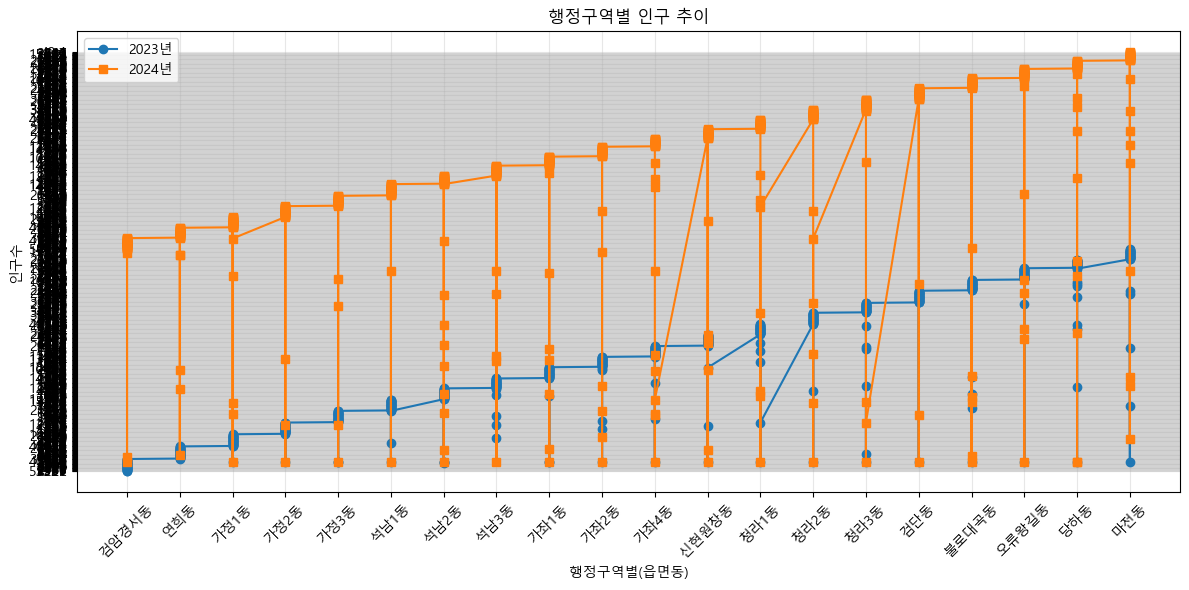

In [35]:
# 특정 항목만 필터링 (예: '총인구(명)')
filtered_df = incheon_seogu[incheon_seogu['항목'] == '총인구(명)']

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(filtered_df['행정구역별(읍면동)'], filtered_df['2023 년'], marker='o', label='2023년')
plt.plot(filtered_df['행정구역별(읍면동)'], filtered_df['2024 년'], marker='s', label='2024년')

plt.xlabel('행정구역별(읍면동)')
plt.ylabel('인구수')
plt.title('행정구역별 인구 추이')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()